# Introduction to Machine Learning - Milestone 2

1. Data Preparation

2. Models and Training

    2.1. Basic CNN

   
    - Training
    - Evaluation
      
    2.2. ResNet 50
      
    - Training
    - Evaluation

    2.3. MobileNetV2

   
    - Training
    - Evaluation
    
    2.4. VGG-style

   
    - Training
    - Evaluation

4. Model Comparison

# 1. Data Preparation

In [1]:
%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

# basic algebra and system libraries
import matplotlib.pyplot as plt
import numpy as np
import os
import os.path as path
import pandas as pd
import gc
from tqdm.notebook import tqdm
import datetime
import seaborn as sns
import random

# signal discrete fourier transform and loading
import scipy.signal as signal
import scipy.io.wavfile as wavfile
import scipy.fft as fft

# audio preprocessing, cross-validation, and others
from sklearn.base import TransformerMixin, BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight, resample
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, precision_score, recall_score


# construction of convolutional neural network
import keras
import keras.optimizers as optimizers
import keras.layers as layers
import keras.losses as losses
import keras.metrics as metrics
import keras.regularizers as regularizers
from tensorflow.keras import Input
from tensorflow.keras.callbacks import TensorBoard

# audio analysis
import librosa
import librosa.display

# processing speedup using GPU
import tensorflow as tf

In [2]:
tf.config.set_visible_devices([], 'GPU')
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [3]:
# Load audio data paths and metadata
metadata = []
data_dir = os.path.join("..", "data", "raw")
class_1_speakers = ['f1', 'f7', 'f8', 'm3', 'm6', 'm8']

for root, dirs, files in os.walk(data_dir):
    for file in files:
        if file.endswith(".wav"):
            speaker_id = file.split('_')[0]
            label = 1 if speaker_id in class_1_speakers else 0
            metadata.append({
                'path': os.path.join(root, file),
                'label': label
            })

metadata_df = pd.DataFrame(metadata)
metadata_df.head()
len(metadata)

100

In [4]:
def load_and_split_audio_with_augmentation(file_path, target_sr=16000, segment_length=1, augment=False, label=None, augment_for_label=1):
    audio, sr = librosa.load(file_path, sr=target_sr)
    total_length = len(audio) / sr
    segments = []
    
    # Split audio into segments of length 'segment_length'
    for start in np.arange(0, total_length, segment_length):
        end = start + segment_length
        segment = audio[int(start * sr):int(end * sr)]
        
        # Pad if the segment is shorter
        if len(segment) < segment_length * sr:
            segment = np.pad(segment, (0, int(segment_length * sr) - len(segment)), mode='constant')
        
        # Apply augmentation only if augment=True and the label matches augment_for_label
        if augment and label == augment_for_label:
            segment = augment_audio(segment, sr=sr)
        
        segments.append(segment)
    
    return segments

def generate_spectrogram_batch(segments, sr=16000):
    spectrograms = []
    for segment in segments:
        # Generate Mel Spectrogram
        S = librosa.feature.melspectrogram(y=segment, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
        S_DB = librosa.power_to_db(S, ref=np.max)
        spectrograms.append(S_DB)
    return spectrograms

# Apply data augmentation
def augment_audio(audio, sr=16000):
    augmented = False

    while not augmented:
        # Time Shifting
        if random.random() < 0.5:
            shift = int(random.uniform(-0.1, 0.1) * sr)  # Shift by ±0.1 seconds
            audio = np.roll(audio, shift)
            augmented = True

        # Pitch Shifting
        if random.random() < 0.5:
            pitch_shift = random.uniform(-2, 2)  # Shift pitch by ±2 semitones
            audio = librosa.effects.pitch_shift(audio, sr=sr, n_steps=pitch_shift)
            augmented = True

        # Time Stretching
        if random.random() < 0.5:
            stretch_factor = random.uniform(0.8, 1.2)  # Stretch by 80%-120%
            audio = librosa.effects.time_stretch(np.asfortranarray(audio), rate=stretch_factor)
            # Ensure the audio length matches the original
            if len(audio) > sr:
                audio = audio[:sr]
            else:
                audio = np.pad(audio, (0, sr - len(audio)), mode='constant')
            augmented = True
        
    # Add Noise
    noise_amp = 0.005 * np.random.uniform() * np.amax(audio)
    audio = audio + noise_amp * np.random.normal(size=audio.shape)
    augmented = True

    return audio

In [5]:
# Specify which labels to augment
labels_to_augment = [1]

# Apply audio splitting and augmentation
metadata_df['segments'] = [
    load_and_split_audio_with_augmentation(
        file_path=x, 
        augment=True if label in labels_to_augment else False,
        label=label,
        augment_for_label=1
    )
    for x, label in tqdm(zip(metadata_df['path'], metadata_df['label']), desc="Loading and Splitting with Augmentation")
]

# Explode the DataFrame to handle individual segments
metadata_df = metadata_df.explode('segments', ignore_index=True)

# Generate spectrograms for all segments
metadata_df['spectrograms'] = [
    generate_spectrogram_batch([segment])[0]
    for segment in tqdm(metadata_df['segments'], desc="Generating Spectrograms")
]

Loading and Splitting with Augmentation: 0it [00:00, ?it/s]

Generating Spectrograms:   0%|          | 0/16149 [00:00<?, ?it/s]

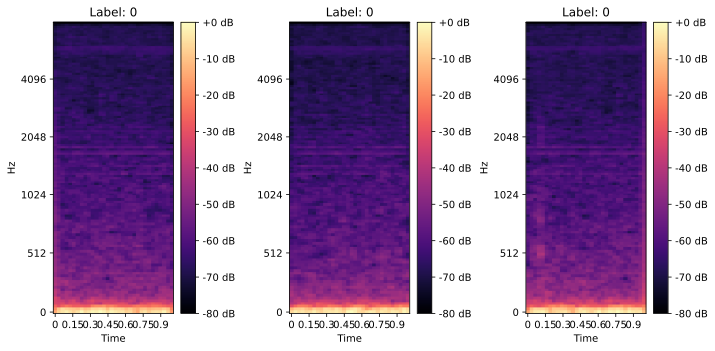

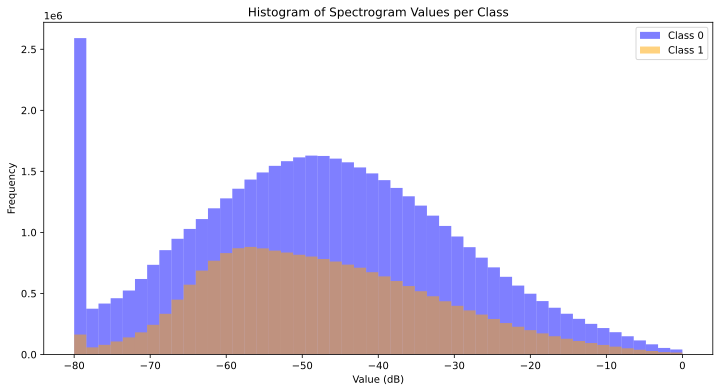

In [6]:
# Plot some example spectrograms
plt.figure(figsize=(10, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    librosa.display.specshow(metadata_df.iloc[i]['spectrograms'], sr=16000, hop_length=512, x_axis='time', y_axis='mel')
    plt.title(f"Label: {metadata_df.iloc[i]['label']}")
    plt.colorbar(format='%+2.0f dB')
plt.tight_layout()
plt.show()

# Histogram of spectrogram values per class
class_0_spectrograms = metadata_df[metadata_df['label'] == 0]['spectrograms'].values
class_1_spectrograms = metadata_df[metadata_df['label'] == 1]['spectrograms'].values

# Flatten spectrogram values
class_0_values = np.concatenate([s.ravel() for s in class_0_spectrograms])
class_1_values = np.concatenate([s.ravel() for s in class_1_spectrograms])

# Plot histograms
plt.figure(figsize=(12, 6))
plt.hist(class_0_values, bins=50, alpha=0.5, label='Class 0', color='blue')
plt.hist(class_1_values, bins=50, alpha=0.5, label='Class 1', color='orange')
plt.title("Histogram of Spectrogram Values per Class")
plt.xlabel("Value (dB)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
# Train-test split before augmentation and audio splitting
train_df, test_df = train_test_split(metadata_df, test_size=0.2, random_state=42, stratify=metadata_df['label'])

# Process training set with augmentation
train_df['segments'] = [
    load_and_split_audio_with_augmentation(
        file_path=x,
        target_sr=16000,
        segment_length=1,
        augment=True,  # Enable augmentation for training data
        label=label,
        augment_for_label=1
    ) for x, label in tqdm(zip(train_df['path'], train_df['label']), desc="Processing Train Audio")
]

# Process test set without augmentation
test_df['segments'] = [
    load_and_split_audio_with_augmentation(
        file_path=x,
        target_sr=16000,
        segment_length=1,
        augment=False,  # No augmentation for test data
        label=label
    ) for x, label in tqdm(zip(test_df['path'], test_df['label']), desc="Processing Test Audio")
]

# Explode the segments for train and test
train_df = train_df.explode('segments')
test_df = test_df.explode('segments')

# Generate spectrograms
train_df['spectrograms'] = generate_spectrogram_batch(train_df['segments'].tolist())
test_df['spectrograms'] = generate_spectrogram_batch(test_df['segments'].tolist())

# Apply oversampling to balance classes in the training data
# Separate majority and minority classes
train_majority = train_df[train_df['label'] == 0]
train_minority = train_df[train_df['label'] == 1]

# Oversample the minority class
train_minority_oversampled = resample(
    train_minority,
    replace=True,
    n_samples=len(train_majority),
    random_state=42
)

# Combine the majority class with the oversampled minority class
train_df_balanced = pd.concat([train_majority, train_minority_oversampled])

# Prepare features and labels from the balanced dataset
X_train = np.stack(train_df_balanced['spectrograms'].values)[..., np.newaxis]
Y_train = train_df_balanced['label'].values

# Prepare the test data
X_test = np.stack(test_df['spectrograms'].values)[..., np.newaxis]
Y_test = test_df['label'].values

Processing Train Audio: 0it [00:00, ?it/s]

Class distribution before augmentation and splitting:
label
0    8894
1    4154
Name: count, dtype: int64

Class distribution after augmentation and oversampling:
label
0    8894
1    8894
Name: count, dtype: int64


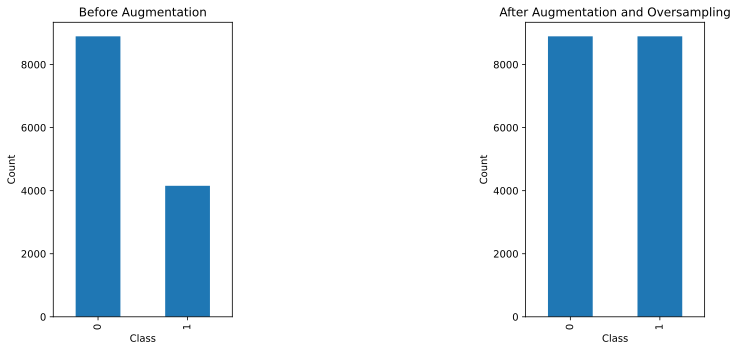

In [27]:
# Check class distribution before augmentation and splitting
print("Class distribution before augmentation and splitting:")
print(train_df['label'].value_counts())

# Check class distribution after oversampling
print("\nClass distribution after augmentation and oversampling:")
print(train_df_balanced['label'].value_counts())

# Plot before augmentation and splitting
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
train_df['label'].value_counts().plot(kind='bar')
plt.title("Before Augmentation")
plt.xlabel("Class")
plt.ylabel("Count")

# Plot after oversampling
plt.subplot(1, 3, 3)
train_df_balanced['label'].value_counts().plot(kind='bar')
plt.title("After Augmentation and Oversampling")
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# 2. Models and Training

## 2.1. Basic CNN

### Training

In [ ]:
# Create basic CNN model
def create_cnn():
    inputs = Input(shape=(128, 32, 1))
    x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

basic_cnn_model = create_cnn()

# Set up TensorBoard callback
log_dir = os.path.join("logs", "fit") + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Train model
basic_cnn_history = basic_cnn_model.fit(
    X_train, Y_train, 
    epochs=10, 
    batch_size=32,
    validation_data=(X_test, Y_test), 
    callbacks=[tensorboard_callback],
    class_weight=dict(enumerate(compute_class_weight('balanced', classes=np.unique(Y_train), y=Y_train)))
)

### Evaluation

In [ ]:
# Plot training history
plt.plot(basic_cnn_history.history['accuracy'], label='accuracy')
plt.plot(basic_cnn_history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

## 2.2. ResNet 50

### Training

In [ ]:
X = np.stack(metadata_df['spectrograms'].values)
X = X[..., np.newaxis]  # Add channel dimension for CNN
Y = metadata_df['label'].values

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Create model
def create_resnet_for_spectrograms():
    base_model = tf.keras.applications.ResNet50V2(
        include_top=False,
        weights=None,  # Don't use ImageNet weights since input is different
        input_shape=(128, 32, 1),  # Your spectrogram shape
        pooling='avg'
    )
    
    # Modify first conv layer to accept single channel
    base_model.layers[0] = tf.keras.layers.Conv2D(
        64, 7, strides=2, padding='same',
        input_shape=(128, 32, 1)
    )
    
    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=optimizers.Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
    return model


resnet_50_model = create_resnet_for_spectrograms()

# Set up TensorBoard callback
log_dir = os.path.join("logs", "fit") + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Train model
resnet_50_history = resnet_50_model.fit(
    X_train, Y_train, 
    epochs=10, 
    batch_size=32,
    validation_data=(X_test, Y_test), 
    callbacks=[tensorboard_callback],
    class_weight=dict(enumerate(compute_class_weight('balanced', classes=np.unique(Y_train), y=Y_train)))
)

### Evaluation

In [ ]:
# Plot training history
plt.plot(resnet_50_history.history['accuracy'], label='accuracy')
plt.plot(resnet_50_history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()


## 2.3. MobileNetV2

### Training

In [ ]:
X = np.stack(metadata_df['spectrograms'].values)
X = X[..., np.newaxis]  # Add channel dimension for CNN
Y = metadata_df['label'].values

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Create model
def create_mobilenetv2_for_spectrograms():
    # Create base MobileNetV2 model
    base_model = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights=None,  # Don't use ImageNet weights since input is different
        input_shape=(128, 32, 1),
        alpha=1.0,  # Controls network width. Use smaller values (0.35, 0.5, 0.75) for faster inference
        pooling='avg'
    )
    
    # Modify first conv layer to accept single channel
    base_model.layers[0] = tf.keras.layers.Conv2D(
        32, kernel_size=3, strides=2, padding='same',
        input_shape=(128, 32, 1)
    )
    
    # Create the model
    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model


mobilenetv2_model = create_mobilenetv2_for_spectrograms()

# Set up TensorBoard callback
log_dir = os.path.join("logs", "fit") + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Train model
mobilenetv2_history = mobilenetv2_model.fit(
    X_train, Y_train, 
    epochs=10, 
    batch_size=32,
    validation_data=(X_test, Y_test), 
    callbacks=[tensorboard_callback],
    class_weight=dict(enumerate(compute_class_weight('balanced', classes=np.unique(Y_train), y=Y_train)))
)

### Evaluation

In [ ]:
# Plot training history
plt.plot(mobilenetv2_history.history['accuracy'], label='accuracy')
plt.plot(mobilenetv2_history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()


## 2.4. VGG-style

### Training

In [ ]:
X = np.stack(metadata_df['spectrograms'].values)
X = X[..., np.newaxis]  # Add channel dimension for CNN
Y = metadata_df['label'].values

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Create model
def create_vgg_for_spectrograms():
    model = tf.keras.Sequential([
        # Input layer
        tf.keras.layers.Input(shape=(128, 32, 1)),
        
        # First block
        tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        # Second block
        tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        # Third block
        tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Fourth block
        tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        # Dense layers
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model


vgg_model = create_vgg_for_spectrograms()

# Set up TensorBoard callback
log_dir = os.path.join("logs", "fit") + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Train model
vgg_history = vgg_model.fit(
    X_train, Y_train, 
    epochs=10, 
    batch_size=32,
    validation_data=(X_test, Y_test), 
    callbacks=[tensorboard_callback],
    class_weight=dict(enumerate(compute_class_weight('balanced', classes=np.unique(Y_train), y=Y_train)))
)


## Evaluation

In [ ]:
# Plot training history
plt.plot(vgg_history.history['accuracy'], label='accuracy')
plt.plot(vgg_history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

# 3. Model Comparison

In [ ]:
# Collect all model histories
histories = {
    'Basic CNN': basic_cnn_history,
    'ResNet50': resnet_50_history,
    'MobileNetV2': mobilenetv2_history,
    'VGG-style': vgg_history
}

# Create subplots for comparing metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot training accuracy comparison
for model_name, history in histories.items():
    ax1.plot(history.history['accuracy'], label=f'{model_name} (train)')
    ax1.plot(history.history['val_accuracy'], label=f'{model_name} (val)', linestyle='--')

ax1.set_title('Model Accuracy Comparison')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True)

# Plot training loss comparison
for model_name, history in histories.items():
    ax2.plot(history.history['loss'], label=f'{model_name} (train)')
    ax2.plot(history.history['val_loss'], label=f'{model_name} (val)', linestyle='--')

ax2.set_title('Model Loss Comparison')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Create comparison table
models = {
    'Basic CNN': basic_cnn_model,
    'ResNet50': resnet_50_model,
    'MobileNetV2': mobilenetv2_model,
    'VGG-style': vgg_model
}

# Evaluate all models and collect metrics
results = []
for model_name, model in models.items():
    # Get final training and validation metrics
    final_train_acc = histories[model_name].history['accuracy'][-1]
    final_val_acc = histories[model_name].history['val_accuracy'][-1]
    final_train_loss = histories[model_name].history['loss'][-1]
    final_val_loss = histories[model_name].history['val_loss'][-1]
    
    # Get model size
    model_size = model.count_params()
    
    # Make predictions on test set
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    
    # Calculate additional metrics
    f1 = f1_score(Y_test, y_pred)
    precision = precision_score(Y_test, y_pred)
    recall = recall_score(Y_test, y_pred)
    
    results.append({
        'Model': model_name,
        'Train Accuracy': f'{final_train_acc:.4f}',
        'Val Accuracy': f'{final_val_acc:.4f}',
        'Train Loss': f'{final_train_loss:.4f}',
        'Val Loss': f'{final_val_loss:.4f}',
        'F1 Score': f'{f1:.4f}',
        'Precision': f'{precision:.4f}',
        'Recall': f'{recall:.4f}',
        'Parameters': f'{model_size:,}'
    })

# Create and display comparison DataFrame
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.set_index('Model')
display(comparison_df)

# Plot confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
axes = axes.ravel()

for idx, (model_name, model) in enumerate(models.items()):
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    cm = confusion_matrix(Y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx])
    axes[idx].set_title(f'{model_name} Confusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.tight_layout()
plt.show()
